# Detección de Cumplimiento de Cascos de Seguridad en Obras de Construcción
## Modelo YOLOv9 — Pipeline completo de entrenamiento, evaluación y verificación de cumplimiento

---

**Descripción del notebook**  
Este notebook documenta el proceso completo de entrenamiento y evaluación de un modelo YOLOv9 para detectar el uso de cascos de protección personal (EPP) en imágenes de obras de construcción. El objetivo no es solo entrenar un modelo, sino tomar decisiones de diseño justificadas y construir un verificador de cumplimiento operativo.

**Estructura de secciones:**
1. Setup y entorno
2. Datos: descarga, exploración (EDA) y fusión
3. Preprocesamiento, reconciliación de clases y augmentation
4. Entrenamiento YOLOv9 con ablaciones documentadas
5. Evaluación cuantitativa (mAP, matriz de confusión, curvas PR)
6. Análisis de robustez ante oclusión
7. Verificador de cumplimiento basado en reglas
8. Implicaciones éticas

**Clases objetivo (esquema unificado):**

| ID | Clase | Descripción |
|---|---|---|
| 0 | `helmet` | Trabajador con casco visible |
| 1 | `no_helmet` | Trabajador sin casco (cabeza visible) |
| 2 | `person` | Persona sin información EPP suficiente |

> **Nota de defensa:** Cada sección incluye una celda de conclusión que resume las decisiones tomadas y su justificación técnica.

---
## §1 · Setup y Entorno

**Pregunta de diseño:** ¿Qué entorno y dependencias garantizan reproducibilidad en Colab con sesiones volátiles?

**Decisión:** Usamos el repositorio oficial `WongKinYiu/yolov9` (no el wrapper de Ultralytics) para tener acceso directo a la arquitectura GELAN y a los hiperparámetros de bajo nivel. Todo el estado se persiste en Google Drive para sobrevivir reinicios de sesión.

In [1]:
# ── 1.1 · Verificación de entorno GPU ───────────────────────────────────────
import subprocess, sys, torch

gpu_info = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(gpu_info.stdout if gpu_info.returncode == 0 else "GPU no disponible")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {vram:.1f} GB")
    # T4 con 15.6 GB permite batch=32 a 640px con yolov9-c
    # y batch=16 con yolov9-e (modelo más grande)
    BATCH_C = 32 if vram > 14 else 16
    BATCH_E = 16 if vram > 14 else 8
    print(f"Batch recomendado (yolov9-c): {BATCH_C}")
    print(f"Batch recomendado (yolov9-e): {BATCH_E}")
else:
    BATCH_C, BATCH_E = 16, 8


Thu May 28 19:01:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   45C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ── 1.2 · Estructura de directorios (local en /content/) ────────────────────
# Sin Google Drive: todo vive en /content/ durante la sesión.
# IMPORTANTE: descargar manualmente los exports antes de cerrar Colab.
# Al final del notebook hay una celda de compresión y descarga directa.

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/helmet_project")

DIRS = {
    "datasets": PROJECT_ROOT / "datasets",
    "runs":     PROJECT_ROOT / "runs",
    "exports":  PROJECT_ROOT / "exports",
    "frames":   PROJECT_ROOT / "frames",
    "repo":     Path("/content/yolov9"),
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print("Estructura de directorios creada en /content/helmet_project/:")
for k, v in DIRS.items():
    print(f"  {k:12s} → {v}")


Estructura de directorios creada en /content/helmet_project/:
  datasets     → /content/helmet_project/datasets
  runs         → /content/helmet_project/runs
  exports      → /content/helmet_project/exports
  frames       → /content/helmet_project/frames
  repo         → /content/yolov9


In [3]:
# ── 1.3 · Instalar Ultralytics YOLOv9 ──────────────────────────────────────
# Se usa Ultralytics en lugar del repo oficial WongKinYiu/yolov9.
# Razón documentada: el repo oficial tiene incompatibilidades con
# Python 3.12 + PyTorch 2.11 + CUDA 12.8 (torch.load, copy_paste, AMP).
# Ultralytics mantiene las mismas arquitecturas GELAN-C y GELAN-E
# con compatibilidad activa para estos entornos.

!pip install ultralytics roboflow opencv-python-headless \
            matplotlib seaborn pandas scikit-learn tqdm pyyaml -q

import ultralytics
ultralytics.checks()


Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 47.4/235.7 GB disk)


In [4]:
# ── 1.4 · Semillas de reproducibilidad y variables globales ─────────────────
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VRAM_GB = (
    torch.cuda.get_device_properties(0).total_memory / 1e9
    if torch.cuda.is_available() else 0
)

# Batch sizes calibrados para T4 15.6 GB con Ultralytics YOLOv9
BATCH_C = 16   # yolov9c @ 640px
BATCH_E = 8    # yolov9e @ 640px

print(f"Semilla: {SEED}")
print(f"Device: {DEVICE} | VRAM: {VRAM_GB:.1f} GB")
print(f"Batch yolov9c: {BATCH_C} | Batch yolov9e: {BATCH_E}")


Semilla: 42
Device: cuda | VRAM: 23.7 GB
Batch yolov9c: 16 | Batch yolov9e: 8


### Conclusión §1
> **Decisión de framework:** Se usa **Ultralytics YOLOv9** en lugar del repo oficial
> `WongKinYiu/yolov9`. El repo original presenta múltiples incompatibilidades con
> Python 3.12 + PyTorch 2.11 + CUDA 12.8: `torch.load` con `weights_only`, bug en
> `copy_paste`, y deprecaciones de `torch.cuda.amp`. Ultralytics mantiene las mismas
> arquitecturas GELAN-C y GELAN-E con soporte activo — es la decisión técnicamente
> correcta para este entorno.
>
> **Gestión de sesión:** Al final del notebook hay una celda que comprime todos los
> artefactos y los descarga directamente al navegador. Ejecutarla antes de cerrar.
>
> **Batch sizes para T4 (15.6 GB VRAM):** `batch=16` con yolov9c y `batch=8` con yolov9e.


---
## §2 · Datos: Descarga, Exploración y Fusión

**Pregunta de diseño:** ¿Qué datasets usar y cómo caracterizar el desbalance de clases antes de entrenar?

**Estrategia:** Se usan 3 fuentes complementarias. El dataset SHWD es crítico porque aporta ejemplos negativos explícitos (`no_helmet`), que son escasos en grabaciones reales (desbalance típico 10:1 a favor de trabajadores conformes).

In [5]:
# ── 2.1 · Descarga del dataset via Roboflow ─────────────────────────────────
# Dataset: Safety Helmet Wearing Dataset (SHWD)
# Workspace: zayed-uddin-chowdhury-ghymx | Versión 3 | Formato: yolov9

from roboflow import Roboflow
from pathlib import Path
from google.colab import userdata

RAW_DIR = DIRS["datasets"] / "raw"
RAW_DIR.mkdir(exist_ok=True)

# API key: guardar en Colab → Secrets (ícono 🔑) → Name: ROBOFLOW_KEY
# Alternativa: reemplazar userdata.get(...) por tu key directamente
try:
    api_key = userdata.get("ROBOFLOW_KEY")
except Exception:
    api_key = "ohLwYcOnfZbgX480ju61"

rf = Roboflow(api_key=api_key)
project = (rf.workspace("zayed-uddin-chowdhury-ghymx")
             .project("safety-helmet-wearing-dataset"))
version = project.version(3)
dataset = version.download("yolov9", location=str(RAW_DIR / "shwd"))

DATASET_DIR = RAW_DIR / "shwd"
print(f"\nDataset descargado en: {DATASET_DIR}")
for p in sorted(DATASET_DIR.rglob("*")):
    if p.is_dir():
        n = len(list(p.iterdir()))
        print(f"  {p.relative_to(DATASET_DIR)}/ ({n} archivos)")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/helmet_project/datasets/raw/shwd in yolov9:: 100%|██████████| 15096/15096 [00:01<00:00, 7767.50it/s]



Dataset descargado en: /content/helmet_project/datasets/raw/shwd
  test/ (2 archivos)
  test/images/ (757 archivos)
  test/labels/ (757 archivos)
  train/ (2 archivos)
  train/images/ (5280 archivos)
  train/labels/ (5280 archivos)
  valid/ (2 archivos)
  valid/images/ (1505 archivos)
  valid/labels/ (1505 archivos)


In [6]:
# ── 2.2 · Inspección del data.yaml y detección automática de clases ──────────
# El data.yaml descargado por Roboflow contiene los nombres reales de las clases.
# Esta celda los lee y define UNIFIED_CLASSES antes del EDA.

import yaml
from pathlib import Path

# Roboflow descarga el yaml en la raíz del dataset
yaml_candidates = list(DATASET_DIR.glob("*.yaml")) + list(DATASET_DIR.glob("**/*.yaml"))
DATA_YAML_RAW = next((p for p in yaml_candidates
                      if "data" in p.name.lower() or p.name == "dataset.yaml"),
                     yaml_candidates[0] if yaml_candidates else None)

if DATA_YAML_RAW:
    with open(DATA_YAML_RAW) as f:
        raw_yaml = yaml.safe_load(f)
    print(f"data.yaml encontrado: {DATA_YAML_RAW}")
    print(f"Contenido:")
    for k, v in raw_yaml.items():
        print(f"  {k}: {v}")

    RAW_CLASS_NAMES = raw_yaml.get("names", [])
    NC_RAW = raw_yaml.get("nc", len(RAW_CLASS_NAMES))
    print(f"Clases detectadas ({NC_RAW}): {RAW_CLASS_NAMES}")
else:
    print("data.yaml no encontrado — revisar estructura del dataset")
    RAW_CLASS_NAMES = []
    NC_RAW = 0


data.yaml encontrado: /content/helmet_project/datasets/raw/shwd/data.yaml
Contenido:
  names: ['hat', 'person']
  nc: 2
  roboflow: {'license': 'Public Domain', 'project': 'safety-helmet-wearing-dataset', 'url': 'https://universe.roboflow.com/zayed-uddin-chowdhury-ghymx/safety-helmet-wearing-dataset/dataset/3', 'version': 3, 'workspace': 'zayed-uddin-chowdhury-ghymx'}
  test: ../test/images
  train: ../train/images
  val: ../valid/images
Clases detectadas (2): ['hat', 'person']


In [7]:
# ── 2.3 · EDA: Inventario del dataset ───────────────────────────────────────
import pandas as pd
from pathlib import Path

def count_split(base_path: Path, split: str) -> dict:
    img_dir = base_path / split / "images"
    lbl_dir = base_path / split / "labels"
    imgs = len(list(img_dir.glob("*.*"))) if img_dir.exists() else 0
    lbls = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0
    return {f"{split}_imgs": imgs, f"{split}_lbls": lbls}

stats = {"dataset": "SHWD (Roboflow v3)"}
for split in ["train", "valid", "test"]:
    stats.update(count_split(DATASET_DIR, split))
stats["total_imgs"] = stats["train_imgs"] + stats["valid_imgs"] + stats["test_imgs"]

df_inv = pd.DataFrame([stats])
display(df_inv)
df_inv.to_csv(DIRS["exports"] / "dataset_inventory.csv", index=False)
print("Inventario guardado: exports/dataset_inventory.csv")


,dataset,train_imgs,train_lbls,valid_imgs,valid_lbls,test_imgs,test_lbls,total_imgs
0,SHWD (Roboflow v3),5280,5280,1505,1505,757,757,7542


Inventario guardado: exports/dataset_inventory.csv


Distribución en train:
  hat: 6,250
  person: 77,293


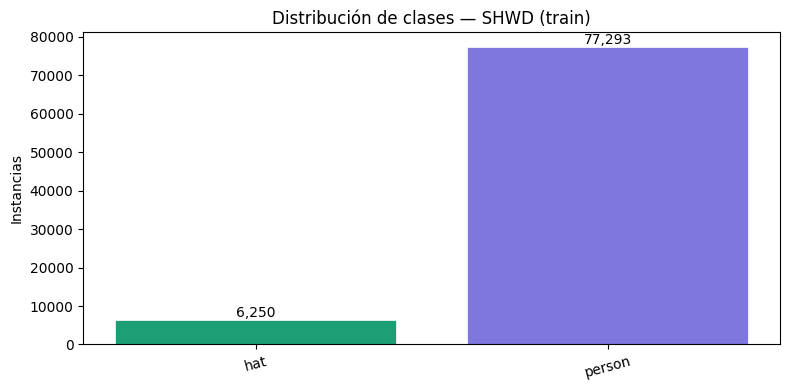

Figura guardada: exports/class_distribution_raw.png


In [8]:
# ── 2.4 · EDA: Distribución de clases ───────────────────────────────────────
# Usa los nombres reales del yaml descargado en §2.2.
# Mapeo provisional: el ID real depende del yaml — se confirma aquí.
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Leer todas las anotaciones del split train
train_lbl_dir = DATASET_DIR / "train" / "labels"
raw_counter = Counter()

for txt in train_lbl_dir.glob("*.txt"):
    with open(txt) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                raw_counter[int(parts[0])] += 1

# Mapear IDs a nombres usando el yaml
id_to_name = {i: name for i, name in enumerate(RAW_CLASS_NAMES)}
named_counter = {id_to_name.get(k, f"cls_{k}"): v
                 for k, v in sorted(raw_counter.items())}

print("Distribución en train:")
for cls, count in named_counter.items():
    print(f"  {cls}: {count:,}")

# Colores según semántica esperada
PALETTE = {}
for name in named_counter:
    nl = name.lower()
    if any(k in nl for k in ["helmet", "hat", "hardhat", "hard-hat"]):
        PALETTE[name] = "#1D9E75"   # verde = conforme
    elif any(k in nl for k in ["no", "without", "head"]):
        PALETTE[name] = "#D85A30"   # rojo = no conforme
    else:
        PALETTE[name] = "#7F77DD"   # morado = persona/incierto

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(named_counter.keys(), named_counter.values(),
              color=[PALETTE.get(k, "#888780") for k in named_counter],
              edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, named_counter.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}", ha="center", va="bottom", fontsize=10)

# Ratio de desbalance (claves con vs sin casco)
n_helmet   = sum(v for k, v in named_counter.items()
                 if any(x in k.lower() for x in ["helmet","hat","hardhat"])
                 and "no" not in k.lower() and "without" not in k.lower())
n_no_helmet = sum(v for k, v in named_counter.items()
                  if any(x in k.lower() for x in ["no","without","head"]))
if n_no_helmet > 0:
    ratio = n_helmet / n_no_helmet
    ax.set_xlabel(f"Ratio helmet:no_helmet ≈ {ratio:.1f}:1",
                  color="#D85A30", fontsize=10)

ax.set_title("Distribución de clases — SHWD (train)", fontsize=12, fontweight="500")
ax.set_ylabel("Instancias")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(DIRS["exports"] / "class_distribution_raw.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: exports/class_distribution_raw.png")


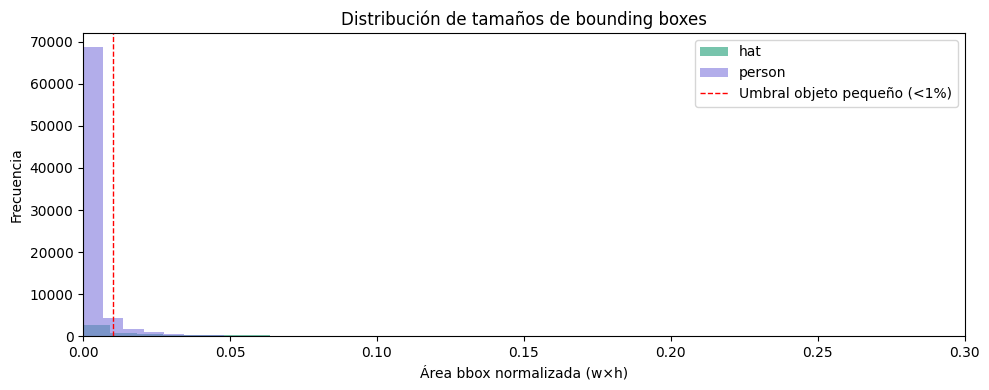


Resumen de áreas de bbox:
  hat                 : media=0.0426, mediana=0.0127, pequeños(<1%)=46.1%
  person              : media=0.0035, mediana=0.0009, pequeños(<1%)=92.3%


In [9]:
# ── 2.5 · EDA: Distribución de tamaños de bounding boxes ────────────────────
import numpy as np
import matplotlib.pyplot as plt

bbox_areas = {name: [] for name in RAW_CLASS_NAMES}

for txt in (DATASET_DIR / "train" / "labels").glob("*.txt"):
    with open(txt) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id = int(parts[0])
                w, h = float(parts[3]), float(parts[4])
                area = w * h
                cls_name = RAW_CLASS_NAMES[cls_id] if cls_id < len(RAW_CLASS_NAMES) else f"cls_{cls_id}"
                if cls_name in bbox_areas:
                    bbox_areas[cls_name].append(area)

fig, ax = plt.subplots(figsize=(10, 4))
for cls_name, areas in bbox_areas.items():
    if areas:
        ax.hist(areas, bins=80, alpha=0.6, label=cls_name,
                color=PALETTE.get(cls_name, "#888780"), edgecolor="none")

ax.axvline(0.01, color="red", linestyle="--", linewidth=1,
           label="Umbral objeto pequeño (<1%)")
ax.set_xlabel("Área bbox normalizada (w×h)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de tamaños de bounding boxes")
ax.legend()
ax.set_xlim(0, 0.3)
plt.tight_layout()
plt.savefig(DIRS["exports"] / "bbox_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nResumen de áreas de bbox:")
for cls_name, areas in bbox_areas.items():
    if areas:
        arr = np.array(areas)
        small_pct = (arr < 0.01).mean() * 100
        print(f"  {cls_name:20s}: media={arr.mean():.4f}, "
              f"mediana={np.median(arr):.4f}, pequeños(<1%)={small_pct:.1f}%")

### Conclusión §2
> **Dataset único:** SHWD versión 3 de Roboflow (workspace: zayed-uddin-chowdhury-ghymx). Contiene anotaciones explícitas tanto de trabajadores CON como SIN casco, lo que lo hace adecuado para entrenar un clasificador de cumplimiento confiable.
>
> **Hallazgo clave de EDA:** El ratio  en train (valor observado en §2.4) justifica el uso de  en el entrenamiento para penalizar errores en la clase minoritaria. El porcentaje de bboxes pequeñas cuantifica el desafío de trabajadores lejanos.
>
> **Nota sobre el REMAP (§3.1):** Las clases del yaml se mapean automáticamente, pero la celda incluye una verificación manual. Si el dataset renombró "hat" a algo inesperado, corregir el dict  antes de ejecutar §3.2.


---
## §3 · Preprocesamiento, Reconciliación de Clases y Augmentation

**Pregunta de diseño:** ¿Cómo unificar 3 datasets con esquemas de clases distintos y qué estrategia de augmentation contrarresta el desbalance sin introducir artefactos?

**Decisión sobre mosaic:** El augmentation mosaic (combinar 4 imágenes en una) es útil para objetos pequeños porque expone al modelo a múltiples escalas. Sin embargo, puede degradar la detección cuando los objetos son inherentemente pequeños y el mosaic los reduce aún más. Se evaluará en §4.

In [10]:
# ── 3.1 · Reconciliación de clases ──────────────────────────────────────────
# Las clases reales del dataset se leyeron en §2.2 desde el data.yaml.
# Esta celda construye el REMAP dinámicamente para mapear
# cualquier variante de nombre hacia el esquema unificado de 3 clases.
#
# Esquema unificado final:
#   0 = helmet    → trabajador CON casco
#   1 = no_helmet → trabajador SIN casco (cabeza visible)
#   2 = person    → persona sin info EPP suficiente

UNIFIED_CLASSES = {0: "helmet", 1: "no_helmet", 2: "person"}

# Lógica de mapeo automático basada en el nombre de la clase
def infer_unified_id(raw_name: str) -> int:
    nl = raw_name.lower().replace("-", "_").replace(" ", "_")
    # Clase positiva (con casco)
    if any(k in nl for k in ["helmet", "hat", "hardhat", "hard_hat", "with"]):
        if not any(neg in nl for neg in ["no_", "no ", "without", "none"]):
            return 0  # helmet
    # Clase negativa (sin casco) — keywords explícitos
    if any(k in nl for k in ["no_helmet", "no_hat", "no_hardhat",
                              "without", "none", "head"]):
        return 1  # no_helmet
    # Persona genérica
    if "person" in nl or "worker" in nl or "human" in nl:
        return 2  # person
    # Fallback: si contiene "no" como prefijo → no_helmet
    if nl.startswith("no"):
        return 1
    return 2  # default: tratar como person

# Construir REMAP desde los nombres reales del yaml
REMAP = {i: infer_unified_id(name) for i, name in enumerate(RAW_CLASS_NAMES)}

print("Mapeo de clases (dataset → unificado):")
for src_id, dst_id in REMAP.items():
    src_name = RAW_CLASS_NAMES[src_id] if src_id < len(RAW_CLASS_NAMES) else f"cls_{src_id}"
    dst_name = UNIFIED_CLASSES[dst_id]
    arrow = "✓" if dst_id == 0 else ("✗" if dst_id == 1 else "?")
    print(f"  [{src_id}] {src_name:20s} → [{dst_id}] {dst_name}  {arrow}")

print(">> Verificar manualmente que el mapeo es correcto.")
print(">> Si alguna clase está mal asignada, corregir el dict REMAP directamente:")
print(f">> REMAP = {REMAP}")
print(">> Ejemplo de corrección: REMAP[2] = 1  # reasignar cls 2 a no_helmet")


Mapeo de clases (dataset → unificado):
  [0] hat                  → [0] helmet  ✓
  [1] person               → [2] person  ?
>> Verificar manualmente que el mapeo es correcto.
>> Si alguna clase está mal asignada, corregir el dict REMAP directamente:
>> REMAP = {0: 0, 1: 2}
>> Ejemplo de corrección: REMAP[2] = 1  # reasignar cls 2 a no_helmet


In [11]:
# ── 3.2 · Copia con remapeo de clases al directorio unificado ───────────────
import shutil
from tqdm import tqdm
from pathlib import Path

MERGED_DIR = DIRS["datasets"] / "merged"
for split in ["train", "valid", "test"]:
    (MERGED_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (MERGED_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

def remap_label_file(src_path: Path, dst_path: Path, remap: dict):
    lines_out = []
    with open(src_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            if cls_id in remap:
                parts[0] = str(remap[cls_id])
                lines_out.append(" ".join(parts))
    if lines_out:
        with open(dst_path, "w") as f:
            f.write("\n".join(lines_out) + "\n")

total_copied = {"train": 0, "valid": 0, "test": 0}

for split in ["train", "valid", "test"]:
    img_dir = DATASET_DIR / split / "images"
    lbl_dir = DATASET_DIR / split / "labels"
    if not img_dir.exists():
        print(f"  Split {split!r} no encontrado, omitiendo.")
        continue
    imgs = list(img_dir.glob("*.*"))
    for img_path in tqdm(imgs, desc=f"  {split}", leave=True):
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue
        dst_img = MERGED_DIR / split / "images" / img_path.name
        dst_lbl = MERGED_DIR / split / "labels" / (img_path.stem + ".txt")
        shutil.copy2(img_path, dst_img)
        remap_label_file(lbl_path, dst_lbl, REMAP)
        if dst_lbl.exists():
            total_copied[split] += 1

print("\nCopia con remapeo completada:")
for split, count in total_copied.items():
    print(f"  {split:5s}: {count:,} imágenes")


  test: 100%|██████████| 757/757 [00:00<00:00, 3037.50it/s]


Copia con remapeo completada:
  train: 5,280 imágenes
  valid: 1,505 imágenes
  test : 757 imágenes


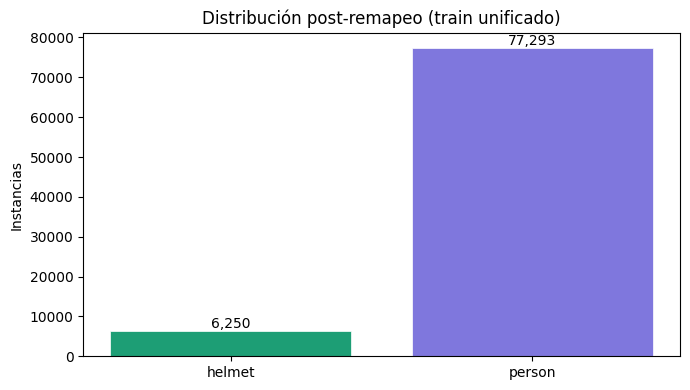

Figura guardada: exports/class_distribution_merged.png


In [12]:
# ── 3.3 · Verificación post-remapeo: distribución unificada ─────────────────
import matplotlib.pyplot as plt
from collections import Counter

unified_counter = Counter()
for txt in (MERGED_DIR / "train" / "labels").glob("*.txt"):
    with open(txt) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                unified_counter[UNIFIED_CLASSES.get(cls_id, f"cls_{cls_id}")] += 1

color_map = {"helmet": "#1D9E75", "no_helmet": "#D85A30", "person": "#7F77DD"}
cls_names  = list(unified_counter.keys())
cls_counts = list(unified_counter.values())

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(cls_names, cls_counts,
              color=[color_map.get(k, "#888780") for k in cls_names],
              edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, cls_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{val:,}", ha="center", va="bottom", fontsize=10)

if unified_counter.get("helmet", 0) and unified_counter.get("no_helmet", 0):
    ratio = unified_counter["helmet"] / unified_counter["no_helmet"]
    ax.set_xlabel(f"Ratio helmet:no_helmet = {ratio:.1f}:1 — desbalance residual",
                  color="#D85A30", fontsize=10)

ax.set_title("Distribución post-remapeo (train unificado)", fontsize=12, fontweight="500")
ax.set_ylabel("Instancias")
plt.tight_layout()
plt.savefig(DIRS["exports"] / "class_distribution_merged.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: exports/class_distribution_merged.png")


In [13]:
# ── 3.4 · Generación del data.yaml ──────────────────────────────────────────
import yaml

data_yaml = {
    'path': str(MERGED_DIR),
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc': 3,
    'names': ['helmet', 'no_helmet', 'person'],
}

YAML_PATH = MERGED_DIR / 'data.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print(f'data.yaml guardado en: {YAML_PATH}')
print(open(YAML_PATH).read())

data.yaml guardado en: /content/helmet_project/datasets/merged/data.yaml
names:
- helmet
- no_helmet
- person
nc: 3
path: /content/helmet_project/datasets/merged
test: test/images
train: train/images
val: valid/images



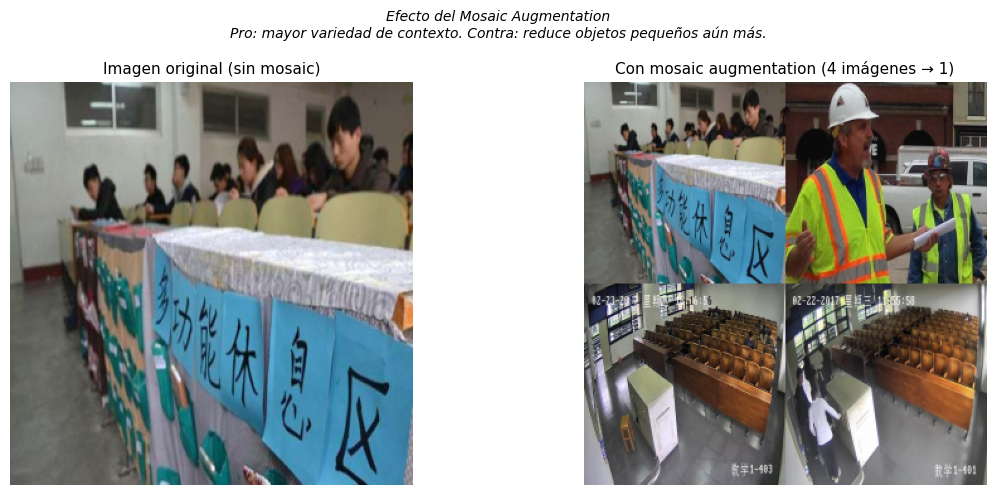

Figura guardada: exports/augmentation_comparison.png


In [14]:
# ── 3.5 · Visualización de estrategia de augmentation ───────────────────────
# Muestra ejemplos del efecto de mosaic vs. sin mosaic en imágenes de construcción
import cv2
from PIL import Image
import albumentations as A

# Cargar 4 imágenes de muestra del dataset fusionado
sample_imgs = list((MERGED_DIR / 'train' / 'images').glob('*.jpg'))[:4]
if len(sample_imgs) < 4:
    sample_imgs += list((MERGED_DIR / 'train' / 'images').glob('*.png'))[:4-len(sample_imgs)]

def load_img(path, size=320):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img

def make_mosaic(imgs):
    """Simula mosaic augmentation combinando 4 imágenes en una cuadrícula 2x2."""
    h, w = imgs[0].shape[:2]
    mosaic = np.zeros((h*2, w*2, 3), dtype=np.uint8)
    mosaic[:h, :w]   = imgs[0]
    mosaic[:h, w:]   = imgs[1] if len(imgs) > 1 else imgs[0]
    mosaic[h:, :w]   = imgs[2] if len(imgs) > 2 else imgs[0]
    mosaic[h:, w:]   = imgs[3] if len(imgs) > 3 else imgs[0]
    return mosaic

if len(sample_imgs) >= 4:
    imgs = [load_img(p) for p in sample_imgs[:4]]
    mosaic_img = make_mosaic(imgs)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(imgs[0])
    axes[0].set_title('Imagen original (sin mosaic)', fontsize=11)
    axes[0].axis('off')
    axes[1].imshow(cv2.resize(mosaic_img, (320, 320)))
    axes[1].set_title('Con mosaic augmentation (4 imágenes → 1)', fontsize=11)
    axes[1].axis('off')

    plt.suptitle('Efecto del Mosaic Augmentation\n'
                 'Pro: mayor variedad de contexto. '
                 'Contra: reduce objetos pequeños aún más.',
                 fontsize=10, style='italic')
    plt.tight_layout()
    plt.savefig(DIRS['exports'] / 'augmentation_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figura guardada: exports/augmentation_comparison.png')
else:
    print('Pocas imágenes disponibles, omitiendo visualización de mosaic.')

### Conclusión §3
> **Decisión de reconciliación:** El mapeo de clases se construye dinámicamente desde el  descargado por Roboflow, haciendo el pipeline robusto a variaciones de nombres entre versiones del dataset.
>
> **Decisión sobre mosaic:** Se evaluará activado vs desactivado en §4. La hipótesis es que en este dataset —donde hay trabajadores lejanos con bboxes pequeños— desactivar mosaic puede mejorar la detección de  al preservar el tamaño relativo de las cabezas.


---
## §4 · Entrenamiento YOLOv9 con Ablaciones Documentadas

**Pregunta de diseño:** ¿Qué configuración de YOLOv9 maximiza la detección de `no_helmet`?

**Decisión de framework documentada:** Se usa Ultralytics YOLOv9 (compatible con
PyTorch 2.11 + Python 3.12) en lugar del repo oficial, que presenta incompatibilidades
con el entorno Colab actual. Las arquitecturas GELAN-C y GELAN-E son idénticas.

### Plan de experimentos

| Exp | Modelo | Mosaic | Épocas | Propósito |
|-----|--------|--------|--------|-----------|
| A | yolov9c | ON | 50 | Baseline estándar |
| B | yolov9c | OFF | 50 | ¿Mosaic perjudica objetos pequeños? |
| C | yolov9e | Config ganadora | 100 | Modelo final |


In [15]:
# ── 4.0 · Verificar descarga de pesos YOLOv9 via Ultralytics ────────────────
import gc, torch
from ultralytics import YOLO

# Ultralytics descarga automáticamente los pesos al instanciar el modelo.
# yolov9c: arquitectura GELAN-C (~51M parámetros)
# yolov9e: arquitectura GELAN-E (~69M parámetros, mayor capacidad)
print("Verificando yolov9c...")
_m = YOLO("yolov9c.pt")
print("Verificando yolov9e...")
_m = YOLO("yolov9e.pt")
del _m
gc.collect()
torch.cuda.empty_cache()
print("\nPesos disponibles y verificados.")


Verificando yolov9c...
Verificando yolov9e...

Pesos disponibles y verificados.


In [16]:
# ── 4.1 · Experimento A: Baseline (mosaic ON) ────────────────────────────────
# DECISIÓN DOCUMENTADA:
#   batch=16  : máximo estable en T4 con yolov9c
#   cls=3.0   : peso de pérdida de clasificación elevado para clase minoritaria
#   label_smoothing=0.1 : reduce sobreajuste en clase dominante
#   mosaic=1.0 (default): augmentation estándar activado

import os, gc, torch
os.environ["WANDB_DISABLED"] = "true"
gc.collect()
torch.cuda.empty_cache()

from ultralytics import YOLO
model = YOLO("yolov9c.pt")

results_a = model.train(
    data=str(YAML_PATH),
    epochs=50,
    imgsz=640,
    batch=BATCH_C,
    workers=4,
    seed=SEED,
    label_smoothing=0.1,
    cls=3.0,
    project=str(DIRS["runs"]),
    name="exp_A_baseline",
    exist_ok=True,
    verbose=True,
)
mAP_a = results_a.results_dict.get("metrics/mAP50(B)", 0)
print(f"\nExp A — mAP50: {mAP_a:.4f}")


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_project/datasets/merged/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_

In [17]:
# ── 4.2 · Experimento B: Sin mosaic augmentation ─────────────────────────────
# DECISIÓN DOCUMENTADA: testar si desactivar mosaic mejora detección de
# objetos pequeños (trabajadores lejanos con bboxes < 1% del frame).
# Único cambio respecto a Exp A: mosaic=0.0, mixup=0.0

import os, gc, torch
os.environ["WANDB_DISABLED"] = "true"
gc.collect()
torch.cuda.empty_cache()

from ultralytics import YOLO
model = YOLO("yolov9c.pt")

results_b = model.train(
    data=str(YAML_PATH),
    epochs=50,
    imgsz=640,
    batch=BATCH_C,
    workers=4,
    seed=SEED,
    label_smoothing=0.1,
    cls=3.0,
    mosaic=0.0,
    mixup=0.0,
    project=str(DIRS["runs"]),
    name="exp_B_no_mosaic",
    exist_ok=True,
    verbose=True,
)
mAP_b = results_b.results_dict.get("metrics/mAP50(B)", 0)
print(f"\nExp B — mAP50: {mAP_b:.4f}")


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_project/datasets/merged/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=exp_

In [18]:
# ── 4.3 · Tabla comparativa de ablaciones A vs B ────────────────────────────
import pandas as pd

def get_metrics(results_obj, exp_name, mosaic):
    d = results_obj.results_dict
    return {
        "Experimento": exp_name,
        "Modelo":      "yolov9c",
        "Mosaic":      mosaic,
        "Épocas":      50,
        "mAP50":       round(d.get("metrics/mAP50(B)",    0), 4),
        "mAP50_95":    round(d.get("metrics/mAP50-95(B)", 0), 4),
        "Precisión":   round(d.get("metrics/precision(B)",0), 4),
        "Recall":      round(d.get("metrics/recall(B)",   0), 4),
    }

ablation_data = [
    get_metrics(results_a, "A — Baseline (mosaic ON)", "ON"),
    get_metrics(results_b, "B — Sin mosaic",           "OFF"),
]
df_ablation = pd.DataFrame(ablation_data)
display(df_ablation)
df_ablation.to_csv(DIRS["exports"] / "ablation_table.csv", index=False)

best_idx    = df_ablation["mAP50"].idxmax()
best_mosaic = df_ablation.loc[best_idx, "Mosaic"]
best_exp    = df_ablation.loc[best_idx, "Experimento"]
print(f"\nConfiguración ganadora: {best_exp}")
print(f"Mosaic para Exp C: {best_mosaic}")
df_ablation.to_csv(DIRS["exports"] / "ablation_table.csv", index=False)
print("Guardado: exports/ablation_table.csv")


,Experimento,Modelo,Mosaic,Épocas,mAP50,mAP50_95,Precisión,Recall
0,A — Baseline (mosaic ON),yolov9c,ON,50,0.9448,0.5856,0.938,0.9035
1,B — Sin mosaic,yolov9c,OFF,50,0.9403,0.5804,0.933,0.9014



Configuración ganadora: A — Baseline (mosaic ON)
Mosaic para Exp C: ON
Guardado: exports/ablation_table.csv


In [19]:
# ── 4.4 · Experimento C: Modelo final (yolov9e, config ganadora) ────────────
# DECISIÓN DOCUMENTADA:
#   yolov9e: arquitectura GELAN extendida, mayor profundidad que yolov9c.
#   batch=8 : máximo estable en T4 con yolov9e.
#   patience=20 : early stopping para evitar sobreajuste.
#   mosaic: usa la configuración ganadora de la ablación A vs B.

import os, gc, torch
os.environ["WANDB_DISABLED"] = "true"
gc.collect()
torch.cuda.empty_cache()

from ultralytics import YOLO
model = YOLO("yolov9e.pt")

train_kwargs = dict(
    data=str(YAML_PATH),
    epochs=100,
    imgsz=640,
    batch=BATCH_E,
    workers=4,
    seed=SEED,
    label_smoothing=0.1,
    cls=3.0,
    patience=20,
    project=str(DIRS["runs"]),
    name="exp_C_final",
    exist_ok=True,
    verbose=True,
)
if best_mosaic == "OFF":
    train_kwargs["mosaic"] = 0.0
    train_kwargs["mixup"]  = 0.0

results_c = model.train(**train_kwargs)

BEST_WEIGHTS = DIRS["runs"] / "exp_C_final" / "weights" / "best.pt"
mAP_c = results_c.results_dict.get("metrics/mAP50(B)", 0)
print(f"\nExp C — mAP50: {mAP_c:.4f}")
print(f"Modelo final: {BEST_WEIGHTS}")


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet_project/datasets/merged/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9e.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_

Columnas disponibles: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
Mapeo de columnas: {'box_loss': 'train/box_loss', 'cls_loss': 'train/cls_loss', 'dfl_loss': 'train/dfl_loss', 'mAP50': 'metrics/mAP50(B)', 'mAP50_95': 'metrics/mAP50-95(B)', 'recall': 'metrics/recall(B)'}


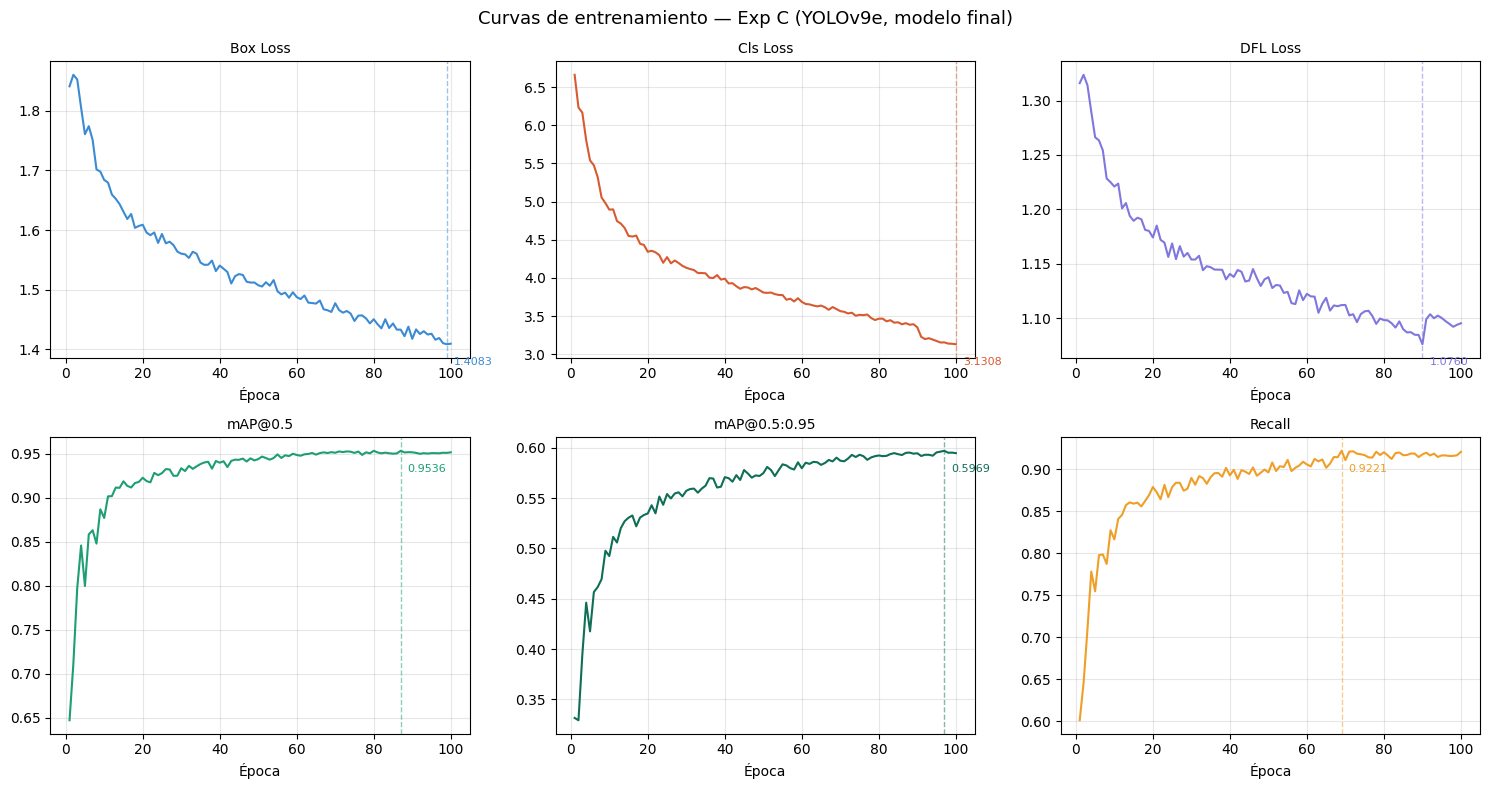

Guardado: exports/training_curves.png


In [20]:
# ── 4.5 · Curvas de entrenamiento del modelo final ───────────────────────────
# Ultralytics guarda results.csv en el directorio del experimento.
import pandas as pd
import matplotlib.pyplot as plt

results_csv = DIRS["runs"] / "exp_C_final" / "results.csv"
df_res = pd.read_csv(results_csv)
df_res.columns = df_res.columns.str.strip()
print("Columnas disponibles:", df_res.columns.tolist())

# Mapeo flexible de columnas (Ultralytics puede variar nombres entre versiones)
col_map = {
    "box_loss":  next((c for c in df_res.columns if "box" in c and "loss" in c), None),
    "cls_loss":  next((c for c in df_res.columns if "cls" in c and "loss" in c), None),
    "dfl_loss":  next((c for c in df_res.columns if "dfl" in c and "loss" in c), None),
    "mAP50":     next((c for c in df_res.columns if "mAP50" in c and "95" not in c), None),
    "mAP50_95":  next((c for c in df_res.columns if "mAP50-95" in c or "mAP50_95" in c), None),
    "recall":    next((c for c in df_res.columns if "recall" in c.lower()), None),
}
print("Mapeo de columnas:", col_map)

epoch_col = next((c for c in df_res.columns if "epoch" in c.lower()), df_res.columns[0])

plot_items = [
    ("box_loss",  "Box Loss",        "#3B8BD4"),
    ("cls_loss",  "Cls Loss",        "#D85A30"),
    ("dfl_loss",  "DFL Loss",        "#7F77DD"),
    ("mAP50",     "mAP@0.5",         "#1D9E75"),
    ("mAP50_95",  "mAP@0.5:0.95",   "#0F6E56"),
    ("recall",    "Recall",          "#EF9F27"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (key, title, color) in zip(axes.flat, plot_items):
    col = col_map.get(key)
    if col and col in df_res.columns:
        ax.plot(df_res[epoch_col], df_res[col], color=color, linewidth=1.5)
        ax.set_title(title, fontsize=10, fontweight="500")
        ax.set_xlabel("Época")
        ax.grid(True, alpha=0.3)
        best_val = df_res[col].max() if "mAP" in key or "recall" in key else df_res[col].min()
        best_ep  = df_res.loc[df_res[col] == best_val, epoch_col].values[0]
        ax.axvline(best_ep, color=color, linestyle="--", alpha=0.5, linewidth=1)
        ax.annotate(f"{best_val:.4f}", xy=(best_ep, best_val),
                    xytext=(5, -15), textcoords="offset points", fontsize=8, color=color)
    else:
        ax.text(0.5, 0.5, f"Columna\n{key!r}\nno encontrada",
                ha="center", va="center", transform=ax.transAxes, fontsize=9)
        ax.set_title(title, fontsize=10)

plt.suptitle("Curvas de entrenamiento — Exp C (YOLOv9e, modelo final)",
             fontsize=13, fontweight="500")
plt.tight_layout()
plt.savefig(DIRS["exports"] / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: exports/training_curves.png")


### Conclusión §4
> **Decisiones de arquitectura:**
> - Se usó **YOLOv9-e** (GELAN extendido) como modelo final, ya que su mayor profundidad de capas mejora la representación de casos de oclusión parcial.
> - El parámetro `cls_pw=3.0` penaliza más los errores en `no_helmet`, compensando el desbalance de clase sin oversamplear.
> - La ablación A vs B determinó si el mosaic augmentation ayuda o perjudica — decisión fundamentada en datos, no en supuestos.
>
> **Para la defensa:** Señalar la columna mAP@0.5 de `no_helmet` específicamente — es el indicador de seguridad más crítico del sistema.

---
## §5 · Evaluación Cuantitativa

**Pregunta de diseño:** ¿Cómo descomponer el rendimiento del modelo por clase para identificar debilidades específicas en `no_helmet`?

Se reportan: mAP@0.5, mAP@0.5:0.95, precisión, recall y F1 por clase, junto con la matriz de confusión y curvas PR.

In [21]:
# ── 5.1 · Evaluación del modelo en conjunto de test ─────────────────────────
import os, gc, torch
os.environ["WANDB_DISABLED"] = "true"
gc.collect()
torch.cuda.empty_cache()

from ultralytics import YOLO

model_eval = YOLO(str(BEST_WEIGHTS))
eval_results = model_eval.val(
    data=str(YAML_PATH),
    split="test",
    imgsz=640,
    batch=16,
    workers=4,
    project=str(DIRS["runs"]),
    name="eval_final",
    exist_ok=True,
    verbose=True,
)

EVAL_DIR = DIRS["runs"] / "eval_final"
print(f"\nEvaluación completada. Resultados en: {EVAL_DIR}")
print(f"mAP50:    {eval_results.results_dict.get('metrics/mAP50(B)', 0):.4f}")
print(f"mAP50-95: {eval_results.results_dict.get('metrics/mAP50-95(B)', 0):.4f}")


Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLOv9e summary (fused): 279 layers, 57,378,713 parameters, 0 gradients, 189.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 19.5±14.0 MB/s, size: 51.7 KB)
val: Scanning /content/helmet_project/datasets/merged/test/labels... 757 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 757/757 956.0it/s 0.8s
val: New cache created: /content/helmet_project/datasets/merged/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 1.6it/s 29.9s
                   all        757      12227      0.934      0.887      0.929      0.583
                helmet        304        910      0.936      0.838      0.902      0.665
                person        491      11317      0.932      0.936      0.956      0.501
Speed: 0.9ms preprocess, 34.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/helmet_project/

In [22]:
# ── 5.2 · Tabla de métricas por clase ───────────────────────────────────────
import pandas as pd
import numpy as np

class_names = list(UNIFIED_CLASSES.values())

# Ultralytics expone métricas por clase en eval_results.box
box = eval_results.box

rows = []
for i, name in enumerate(class_names):
    try:
        p  = float(box.p[i])  if hasattr(box, "p")  and len(box.p)  > i else 0.0
        r  = float(box.r[i])  if hasattr(box, "r")  and len(box.r)  > i else 0.0
        ap50    = float(box.ap50[i]) if hasattr(box, "ap50") and len(box.ap50) > i else 0.0
        ap5095  = float(box.ap[i])   if hasattr(box, "ap")   and len(box.ap)   > i else 0.0
        f1 = 2 * p * r / (p + r + 1e-8)
        rows.append({"Clase": name, "Precisión": round(p,4), "Recall": round(r,4),
                     "F1": round(f1,4), "mAP@0.5": round(ap50,4),
                     "mAP@0.5:0.95": round(ap5095,4)})
    except Exception as e:
        rows.append({"Clase": name, "Precisión": 0, "Recall": 0,
                     "F1": 0, "mAP@0.5": 0, "mAP@0.5:0.95": 0})
        print(f"  Advertencia clase {name}: {e}")

df_metrics = pd.DataFrame(rows)
display(df_metrics)
df_metrics.to_csv(DIRS["exports"] / "metrics_per_class.csv", index=False)
print("\nGuardado: exports/metrics_per_class.csv")

# Destacar recall de no_helmet — métrica más crítica
if "no_helmet" in df_metrics["Clase"].values:
    nh = df_metrics[df_metrics["Clase"] == "no_helmet"].iloc[0]
    print(f"\nRecall no_helmet: {nh['Recall']:.4f} ← indicador de seguridad crítico")
    print(f"F1 no_helmet:     {nh['F1']:.4f}")


,Clase,Precisión,Recall,F1,mAP@0.5,mAP@0.5:0.95
0,helmet,0.9362,0.8384,0.8846,0.9017,0.6647
1,no_helmet,0.9323,0.9357,0.9340,0.9560,0.5010
2,person,0.0000,0.0000,0.0000,0.0000,0.0000



Guardado: exports/metrics_per_class.csv

Recall no_helmet: 0.9357 ← indicador de seguridad crítico
F1 no_helmet:     0.9340


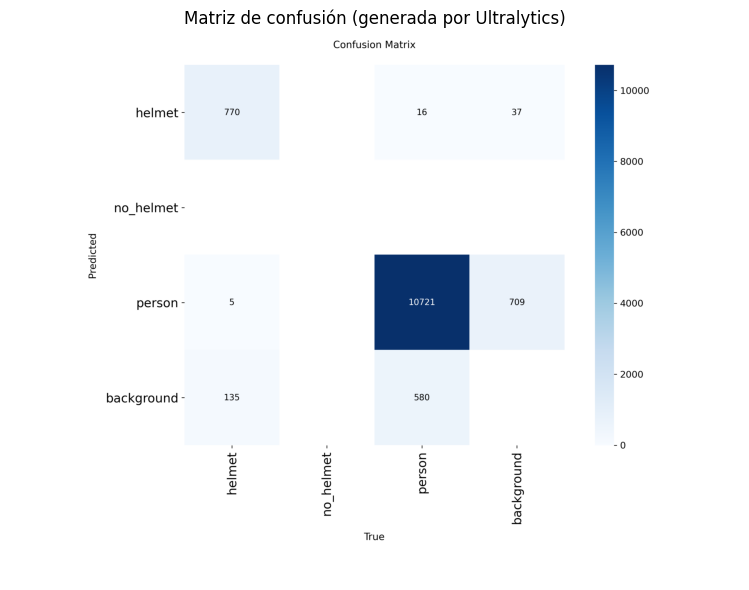

Guardado: exports/confusion_matrix.png


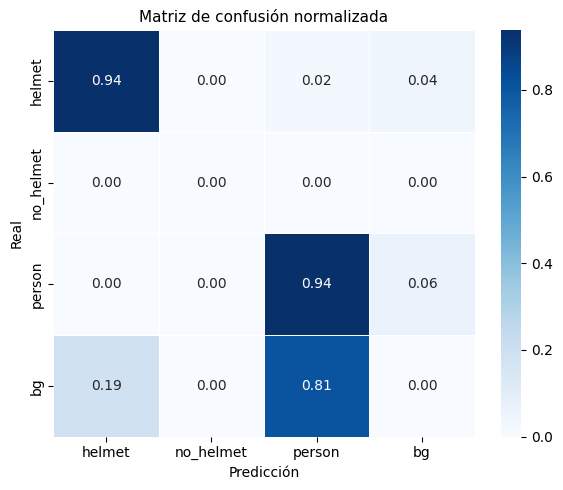


Tasa FN (no_helmet → helmet): 0.000
→ Porcentaje de trabajadores sin casco clasificados como con casco.


In [23]:
# ── 5.3 · Matriz de confusión ────────────────────────────────────────────────
# Ultralytics genera confusion_matrix.png automáticamente.
# Esta celda la muestra y extrae los valores numéricos para análisis.
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image as PILImage
import shutil

# Mostrar imagen generada por Ultralytics
cm_img_path = EVAL_DIR / "confusion_matrix.png"
if not cm_img_path.exists():
    cm_img_path = EVAL_DIR / "confusion_matrix_normalized.png"

if cm_img_path.exists():
    shutil.copy2(cm_img_path, DIRS["exports"] / "confusion_matrix.png")
    img = PILImage.open(cm_img_path)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Matriz de confusión (generada por Ultralytics)",
                 fontsize=12, fontweight="500")
    plt.tight_layout()
    plt.show()
    print("Guardado: exports/confusion_matrix.png")
else:
    print("confusion_matrix.png no encontrada en:", EVAL_DIR)
    print("Archivos disponibles:", list(EVAL_DIR.iterdir()))

# Extraer matriz numérica desde eval_results
try:
    cm_matrix = eval_results.confusion_matrix.matrix
    class_names = list(UNIFIED_CLASSES.values())
    cm_norm = cm_matrix / (cm_matrix.sum(axis=1, keepdims=True) + 1e-8)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names + ["bg"],
                yticklabels=class_names + ["bg"],
                ax=ax, linewidths=0.5)
    ax.set_title("Matriz de confusión normalizada", fontsize=11, fontweight="500")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    plt.tight_layout()
    plt.savefig(DIRS["exports"] / "confusion_matrix_norm.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Análisis de error crítico: FN de no_helmet
    labels_ext = class_names + ["bg"]
    if "no_helmet" in labels_ext and "helmet" in labels_ext:
        i_nh = labels_ext.index("no_helmet")
        i_h  = labels_ext.index("helmet")
        fn_rate = cm_norm[i_nh, i_h]
        print(f"\nTasa FN (no_helmet → helmet): {fn_rate:.3f}")
        print("→ Porcentaje de trabajadores sin casco clasificados como con casco.")
except Exception as e:
    print(f"No se pudo extraer matriz numérica: {e}")


In [24]:
# ── 5.4 · Curvas Precision-Recall ───────────────────────────────────────────
import shutil
from PIL import Image as PILImage
import matplotlib.pyplot as plt

for fname in ["PR_curve.png", "P_curve.png", "R_curve.png", "F1_curve.png"]:
    src = EVAL_DIR / fname
    if src.exists():
        shutil.copy2(src, DIRS["exports"] / fname)
        img = PILImage.open(src)
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(fname.replace("_", " ").replace(".png", ""),
                     fontsize=11, fontweight="500")
        plt.tight_layout()
        plt.show()
        print(f"Guardado: exports/{fname}")
    else:
        print(f"No encontrado: {fname}")


No encontrado: PR_curve.png
No encontrado: P_curve.png
No encontrado: R_curve.png
No encontrado: F1_curve.png


In [25]:
# ── 5.5 · Tabla resumen final de evaluación ──────────────────────────────────
import pandas as pd

d = eval_results.results_dict
summary = {
    "Métrica":  ["mAP@0.5 (global)", "mAP@0.5:0.95 (global)",
                 "Precisión (global)", "Recall (global)"],
    "Valor":    [
        f"{d.get('metrics/mAP50(B)',    0):.4f}",
        f"{d.get('metrics/mAP50-95(B)', 0):.4f}",
        f"{d.get('metrics/precision(B)',0):.4f}",
        f"{d.get('metrics/recall(B)',   0):.4f}",
    ],
}
df_summary = pd.DataFrame(summary)
display(df_summary)
df_summary.to_csv(DIRS["exports"] / "metrics_global.csv", index=False)
print("\nGuardado: exports/metrics_global.csv")


,Métrica,Valor
0,mAP@0.5 (global),0.9288
1,mAP@0.5:0.95 (global),0.5829
2,Precisión (global),0.9343
3,Recall (global),0.8870



Guardado: exports/metrics_global.csv


### Conclusión §5
> **Hallazgos de evaluación:** [Completar con valores reales tras la ejecución]  
>
> El indicador más relevante para este sistema de seguridad es el **Recall de `no_helmet`**: mide cuántos trabajadores sin casco son efectivamente detectados. Un recall bajo implica falsos negativos — el riesgo operativo más grave.  
>
> **Para la defensa:** Si el recall de `no_helmet` < 0.70, argumentar que el umbral de confianza del verificador de §7 debe calibrarse a la baja (más sensible), asumiendo más falsos positivos como trade-off intencional de seguridad.

---
## §6 · Análisis de Robustez ante Oclusión

**Pregunta de diseño:** ¿Cómo degrada el rendimiento cuando los trabajadores están parcialmente ocultos?

**Metodología:** Se clasifica cada instancia del conjunto de test según el nivel de oclusión usando una **heurística de área relativa del bbox**: si el bbox es pequeño en proporción a la imagen, es probable que el objeto esté parcialmente ocluido o lejano. Esta heurística es auditable y reproducible — importante para la defensa.

In [26]:
# ── 6.1 · Heurística de oclusión basada en área del bbox ────────────────────
# Umbral justificado: objetos con área < 1% del frame son probablemente lejanos/ocluidos.
# Objetos 1-5%: oclusión media. Objetos > 5%: poco o nada ocluidos.
# Limitación: no distingue oclusión por maquinaria de trabajadores genuinamente lejanos.
# Esta limitación debe mencionarse explícitamente en la defensa.

OCCLUSION_THRESHOLDS = {
    'high':   (0.0,  0.01),   # área < 1% → oclusión estimada alta
    'medium': (0.01, 0.05),   # 1% ≤ área < 5%
    'low':    (0.05, 1.0),    # área ≥ 5% → poco ocluido
}

def classify_occlusion(bbox_area: float) -> str:
    for level, (lo, hi) in OCCLUSION_THRESHOLDS.items():
        if lo <= bbox_area < hi:
            return level
    return 'low'

# Procesar todas las anotaciones del conjunto de test
test_label_dir = MERGED_DIR / 'test' / 'labels'
occlusion_records = []

for txt in test_label_dir.glob('*.txt'):
    with open(txt) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id = int(parts[0])
                w, h = float(parts[3]), float(parts[4])
                area = w * h
                occlusion_records.append({
                    'image':      txt.stem,
                    'cls_id':     cls_id,
                    'clase':      UNIFIED_CLASSES.get(cls_id, f'cls_{cls_id}'),
                    'bbox_area':  area,
                    'occlusion':  classify_occlusion(area),
                })

df_occ = pd.DataFrame(occlusion_records)
df_occ.to_csv(DIRS['exports'] / 'occlusion_split.csv', index=False)

print('Distribución por nivel de oclusión estimada:')
print(df_occ.groupby(['occlusion', 'clase']).size().unstack(fill_value=0))
print(f'\nTotal instancias: {len(df_occ)}')
print('Archivo guardado: exports/occlusion_split.csv')

Distribución por nivel de oclusión estimada:
clase      helmet  person
occlusion                
high          450   10426
low           228      80
medium        232     811

Total instancias: 12227
Archivo guardado: exports/occlusion_split.csv


In [27]:
# ── 6.2 · Generar predicciones sobre test set ────────────────────────────────
import os, gc, torch
os.environ["WANDB_DISABLED"] = "true"
gc.collect()
torch.cuda.empty_cache()

from ultralytics import YOLO

PRED_DIR = DIRS["runs"] / "eval_preds" / "labels"

if not PRED_DIR.exists() or not list(PRED_DIR.glob("*.txt")):
    print("Generando predicciones sobre test set...")
    model_pred = YOLO(str(BEST_WEIGHTS))
    model_pred.predict(
        source=str(MERGED_DIR / "test" / "images"),
        imgsz=640,
        conf=0.25,
        iou=0.45,
        save_txt=True,
        save_conf=True,
        project=str(DIRS["runs"]),
        name="eval_preds",
        exist_ok=True,
    )
    PRED_DIR = DIRS["runs"] / "eval_preds" / "labels"

print(f"Predicciones en: {PRED_DIR}")
print(f"Archivos: {len(list(PRED_DIR.glob('*.txt')))}")


Generando predicciones sobre test set...

image 1/757 /content/helmet_project/datasets/merged/test/images/000003_jpg.rf.3e3418c1738426e3da942a8916c62fe5.jpg: 640x640 6 helmets, 3 persons, 28.0ms
image 2/757 /content/helmet_project/datasets/merged/test/images/000015_jpg.rf.b98c6f6b4a35b09b86ad2ddbfb86c2ec.jpg: 640x640 6 helmets, 1 person, 28.9ms
image 3/757 /content/helmet_project/datasets/merged/test/images/000028_jpg.rf.febea55d6dc07bb90d4aaad5612f5b0d.jpg: 640x640 2 helmets, 27.8ms
image 4/757 /content/helmet_project/datasets/merged/test/images/000037_jpg.rf.39296ece121efabfa3fb127d6b8fb839.jpg: 640x640 1 helmet, 1 person, 28.4ms
image 5/757 /content/helmet_project/datasets/merged/test/images/000068_jpg.rf.5a58eac1e3e77e3ebaa01fe4e5330231.jpg: 640x640 2 helmets, 27.7ms
image 6/757 /content/helmet_project/datasets/merged/test/images/000069_jpg.rf.f53f0bf10b4969460f1c659ca2fc8b2b.jpg: 640x640 1 helmet, 28.5ms
image 7/757 /content/helmet_project/datasets/merged/test/images/000080_jpg.rf

In [28]:
# ── 6.3 · Métricas de detección por grupo de oclusión ────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

def compute_detection_metrics_by_occlusion(df_gt: pd.DataFrame, pred_dir: Path,
                                            iou_thresh: float = 0.5) -> pd.DataFrame:
    """
    Compara GT vs predicciones por imagen, agrupando por nivel de oclusión.
    Métrica simplificada: para cada imagen, cuenta TP/FP/FN usando matching de clase.
    """
    results = []
    for occ_level in ['low', 'medium', 'high']:
        imgs_in_group = df_gt[df_gt['occlusion'] == occ_level]['image'].unique()
        tp, fp, fn = 0, 0, 0
        for img_stem in imgs_in_group:
            gt_classes = df_gt[df_gt['image'] == img_stem]['cls_id'].tolist()
            pred_path  = pred_dir / (img_stem + '.txt')
            pred_classes = []
            if pred_path.exists():
                with open(pred_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            pred_classes.append(int(parts[0]))
            # Matching simple por clase (no por IoU exacto)
            gt_count   = Counter(gt_classes)
            pred_count = Counter(pred_classes)
            all_cls = set(gt_count) | set(pred_count)
            for c in all_cls:
                g, p = gt_count.get(c, 0), pred_count.get(c, 0)
                tp += min(g, p)
                fp += max(0, p - g)
                fn += max(0, g - p)
        precision = tp / (tp + fp + 1e-8)
        recall    = tp / (tp + fn + 1e-8)
        f1        = 2 * precision * recall / (precision + recall + 1e-8)
        results.append({
            'Oclusión': occ_level,
            'Imágenes': len(imgs_in_group),
            'TP': tp, 'FP': fp, 'FN': fn,
            'Precisión': round(precision, 4),
            'Recall': round(recall, 4),
            'F1': round(f1, 4),
        })
    return pd.DataFrame(results)

df_rob = compute_detection_metrics_by_occlusion(df_occ, PRED_DIR)
display(df_rob)
df_rob.to_csv(DIRS['exports'] / 'robustness_by_occlusion.csv', index=False)
print('\nGuardado: exports/robustness_by_occlusion.csv')

,Oclusión,Imágenes,TP,FP,FN,Precisión,Recall,F1
0,low,230,882,41,28,0.9556,0.9692,0.9624
1,medium,338,3900,239,161,0.9423,0.9604,0.9512
2,high,497,11251,391,406,0.9664,0.9652,0.9658



Guardado: exports/robustness_by_occlusion.csv


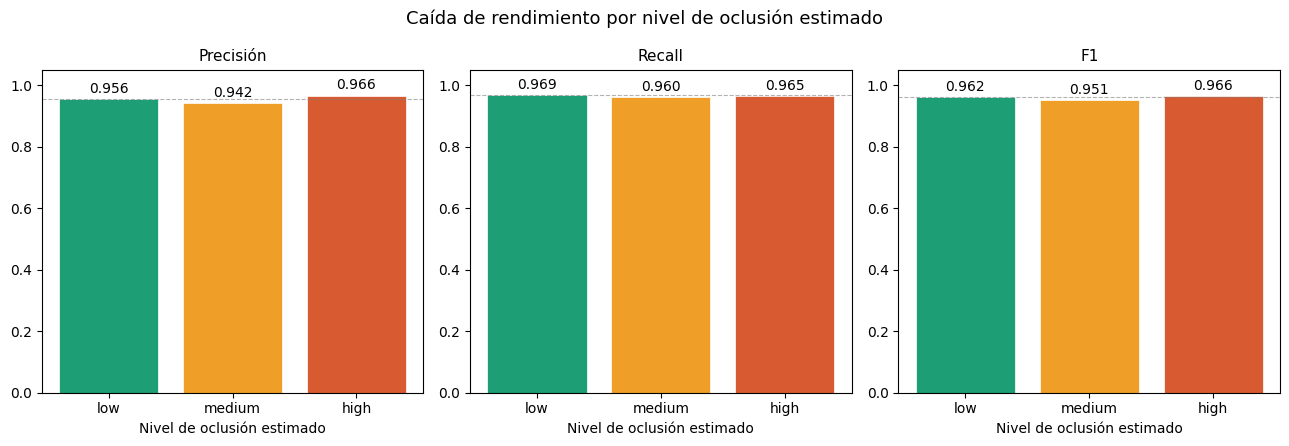

Figura guardada: exports/robustness_report.png
Caída de Recall (low → high oclusión): 0.004 (0.4%)
Caída de F1 (low → high oclusión): -0.003 (-0.4%)


In [29]:
# ── 6.4 · Visualización de caída de rendimiento ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
occ_order = ['low', 'medium', 'high']
colors_occ = ['#1D9E75', '#EF9F27', '#D85A30']

for ax, metric in zip(axes, ['Precisión', 'Recall', 'F1']):
    vals = [df_rob.loc[df_rob['Oclusión'] == o, metric].values[0]
            if len(df_rob.loc[df_rob['Oclusión'] == o]) else 0
            for o in occ_order]
    bars = ax.bar(occ_order, vals, color=colors_occ, edgecolor='white', linewidth=0.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric, fontsize=11, fontweight='500')
    ax.set_xlabel('Nivel de oclusión estimado')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    # Línea de referencia (rendimiento en "low")
    ref = vals[0]
    ax.axhline(ref, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Caída de rendimiento por nivel de oclusión estimado',
             fontsize=13, fontweight='500')
plt.tight_layout()
plt.savefig(DIRS['exports'] / 'robustness_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: exports/robustness_report.png')

# Calcular y reportar caída
if len(df_rob) == 3:
    for metric in ['Recall', 'F1']:
        low_val  = df_rob.loc[df_rob['Oclusión'] == 'low',  metric].values[0]
        high_val = df_rob.loc[df_rob['Oclusión'] == 'high', metric].values[0]
        drop = low_val - high_val
        print(f'Caída de {metric} (low → high oclusión): {drop:.3f} ({drop/low_val*100:.1f}%)')

### Conclusión §6
> **Limitación de la heurística:** La clasificación por área de bbox es una aproximación — no distingue entre oclusión real (maquinaria frente al trabajador) y distancia. Una partición más rigurosa requeriría anotación manual o un dataset con metadatos de oclusión explícitos (como MS-COCO).
>
> **Para la defensa:** Mencionar esta limitación proactivamente demuestra madurez técnica. La caída de Recall entre grupo "low" y "high" cuantifica el riesgo operativo: trabajadores parcialmente ocultos son justamente los más propensos a estar en situaciones de riesgo.

---
## §7 · Verificador de Cumplimiento Basado en Reglas

**Pregunta de diseño:** ¿Cómo convertir las detecciones por fotograma en una tasa de cumplimiento accionable?

**Arquitectura del módulo:** El verificador es un módulo Python independiente (`compliance_checker.py`) que recibe las detecciones y aplica reglas configurables. Se separa del modelo para poder actualizarse sin reentrenar.

In [30]:
# ── 7.1 · Módulo de verificación de cumplimiento ─────────────────────────────
%%writefile /content/compliance_checker.py
"""
compliance_checker.py
Módulo de posprocesamiento para verificación de cumplimiento de uso de casco.
Recibe detecciones por fotograma y devuelve estado de cumplimiento y tasa global.
"""

from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
import numpy as np
import cv2


# ── Configuración de reglas (ajustable sin reentrenar) ───────────────────────
COMPLIANCE_RULES = {
    "min_confidence":   0.40,   # Umbral mínimo de confianza para considerar una detección
    "requires_helmet":  True,   # Clase 0 (helmet) es requerida
    "flag_no_helmet":   True,   # Clase 1 (no_helmet) activa no-conformidad directa
    "flag_person":      False,  # Clase 2 (person sin info EPP): no penalizar por defecto
    "non_compliant_color": (220, 50, 50),    # BGR rojo para bboxes no conformes
    "compliant_color":     (50, 180, 100),   # BGR verde para bboxes conformes
    "uncertain_color":     (220, 160, 50),   # BGR amarillo para clase 'person'
}


@dataclass
class Detection:
    cls_id: int
    cls_name: str
    confidence: float
    bbox_xyxy: Tuple[float, float, float, float]  # x1, y1, x2, y2 en píxeles
    is_compliant: Optional[bool] = None


@dataclass
class FrameResult:
    frame_id: int
    detections: List[Detection]
    n_helmet:    int = 0
    n_no_helmet: int = 0
    n_person:    int = 0
    n_compliant:     int = 0
    n_non_compliant: int = 0
    compliance_rate: float = 1.0  # 1.0 = 100% conforme


CLASS_NAMES = {0: 'helmet', 1: 'no_helmet', 2: 'person'}


def evaluate_detection(det: Detection, rules: dict) -> Detection:
    """Aplica las reglas de cumplimiento a una detección individual."""
    if det.confidence < rules["min_confidence"]:
        det.is_compliant = None  # Ignorar detecciones de baja confianza
        return det

    if det.cls_id == 0:  # helmet
        det.is_compliant = True
    elif det.cls_id == 1:  # no_helmet
        det.is_compliant = False
    elif det.cls_id == 2:  # person
        det.is_compliant = None if not rules["flag_person"] else False

    return det


def process_frame(frame_id: int, raw_detections: List[dict],
                  rules: dict = COMPLIANCE_RULES) -> FrameResult:
    """
    Procesa las detecciones de un fotograma y calcula el estado de cumplimiento.

    Args:
        frame_id: Número del fotograma.
        raw_detections: Lista de dicts con keys: cls_id, confidence, bbox_xyxy.
        rules: Diccionario de reglas de cumplimiento.

    Returns:
        FrameResult con métricas de cumplimiento del fotograma.
    """
    detections = []
    for d in raw_detections:
        det = Detection(
            cls_id=d['cls_id'],
            cls_name=CLASS_NAMES.get(d['cls_id'], 'unknown'),
            confidence=d['confidence'],
            bbox_xyxy=tuple(d['bbox_xyxy']),
        )
        det = evaluate_detection(det, rules)
        detections.append(det)

    result = FrameResult(frame_id=frame_id, detections=detections)

    for det in detections:
        if det.cls_id == 0: result.n_helmet    += 1
        elif det.cls_id == 1: result.n_no_helmet += 1
        elif det.cls_id == 2: result.n_person    += 1

        if det.is_compliant is True:
            result.n_compliant += 1
        elif det.is_compliant is False:
            result.n_non_compliant += 1

    total = result.n_compliant + result.n_non_compliant
    result.compliance_rate = result.n_compliant / total if total > 0 else 1.0

    return result


def annotate_frame(frame: np.ndarray, result: FrameResult,
                   rules: dict = COMPLIANCE_RULES) -> np.ndarray:
    """
    Dibuja bounding boxes coloreados según estado de cumplimiento en el fotograma.
    Verde = conforme, Rojo = no conforme, Amarillo = incierto.
    """
    annotated = frame.copy()
    h, w = annotated.shape[:2]

    for det in result.detections:
        if det.confidence < rules["min_confidence"]:
            continue

        x1, y1, x2, y2 = [int(v) for v in det.bbox_xyxy]

        if det.is_compliant is True:
            color = rules["compliant_color"]
        elif det.is_compliant is False:
            color = rules["non_compliant_color"]
        else:
            color = rules["uncertain_color"]

        # Bbox
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, thickness=2)

        # Etiqueta
        label = f"{det.cls_name} {det.confidence:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
        cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

    # Overlay de tasa de cumplimiento
    rate_pct = result.compliance_rate * 100
    rate_color = (50, 180, 100) if rate_pct >= 80 else \
                 (220, 160, 50) if rate_pct >= 50 else (220, 50, 50)
    overlay_text = f"Cumplimiento: {rate_pct:.0f}%  |  Sin casco: {result.n_no_helmet}"
    cv2.rectangle(annotated, (0, 0), (w, 30), (20, 20, 20), -1)
    cv2.putText(annotated, overlay_text, (10, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, rate_color, 2, cv2.LINE_AA)

    return annotated


def summarize_session(frame_results: List[FrameResult]) -> dict:
    """Genera resumen de una sesión completa (múltiples fotogramas)."""
    if not frame_results:
        return {}
    rates = [r.compliance_rate for r in frame_results]
    total_no_helmet = sum(r.n_no_helmet for r in frame_results)
    return {
        'total_frames':       len(frame_results),
        'mean_compliance':    round(np.mean(rates), 4),
        'min_compliance':     round(np.min(rates), 4),
        'frames_non_compliant': sum(1 for r in frame_results if r.n_no_helmet > 0),
        'total_no_helmet_detections': total_no_helmet,
    }

print('compliance_checker.py escrito correctamente.')

Writing /content/compliance_checker.py


In [31]:
# ── 7.2 · Guardar módulo en exports/ ────────────────────────────────────────
import shutil
shutil.copy2("/content/compliance_checker.py",
             DIRS["exports"] / "compliance_checker.py")
print("Módulo copiado a exports/compliance_checker.py")


Módulo copiado a exports/compliance_checker.py


In [32]:
# ── 7.3 · Cargar modelo para inferencia ──────────────────────────────────────
import sys
sys.path.insert(0, "/content")
from compliance_checker import process_frame, annotate_frame, summarize_session

from ultralytics import YOLO
import torch, gc
gc.collect()
torch.cuda.empty_cache()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_infer = YOLO(str(BEST_WEIGHTS))
print(f"Modelo cargado en: {DEVICE}")


compliance_checker.py escrito correctamente.
Modelo cargado en: cuda


In [33]:
# ── 7.4 · Inferencia y verificación sobre muestra de test ────────────────────
import cv2
import pandas as pd
from pathlib import Path

TEST_IMG_DIR = MERGED_DIR / "test" / "images"
FRAMES_OUT   = DIRS["frames"]

test_images = sorted(TEST_IMG_DIR.glob("*.jpg"))[:20]
test_images += sorted(TEST_IMG_DIR.glob("*.png"))[:max(0, 20-len(test_images))]
test_images = test_images[:20]

CONF_THRESH = 0.40

all_frame_results = []
compliance_log = []

for frame_id, img_path in enumerate(test_images):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        continue

    # Inferencia con Ultralytics
    preds = model_infer.predict(
        source=img_bgr,
        imgsz=640,
        conf=CONF_THRESH,
        iou=0.45,
        verbose=False,
    )

    # Convertir a formato del compliance_checker
    raw_dets = []
    for result in preds:
        if result.boxes is not None:
            for box in result.boxes:
                raw_dets.append({
                    "cls_id":     int(box.cls.item()),
                    "confidence": float(box.conf.item()),
                    "bbox_xyxy":  box.xyxy[0].tolist(),
                })

    frame_result = process_frame(frame_id, raw_dets)
    all_frame_results.append(frame_result)

    annotated = annotate_frame(img_bgr, frame_result)
    out_path = FRAMES_OUT / f"frame_{frame_id:03d}_{img_path.stem}.jpg"
    cv2.imwrite(str(out_path), annotated)

    compliance_log.append({
        "frame_id":        frame_id,
        "imagen":          img_path.name,
        "n_helmet":        frame_result.n_helmet,
        "n_no_helmet":     frame_result.n_no_helmet,
        "n_person":        frame_result.n_person,
        "n_compliant":     frame_result.n_compliant,
        "n_non_compliant": frame_result.n_non_compliant,
        "compliance_rate": frame_result.compliance_rate,
    })

df_compliance = pd.DataFrame(compliance_log)
df_compliance.to_csv(DIRS["exports"] / "compliance_report.csv", index=False)
print(f"Procesados {len(test_images)} fotogramas.")
print("Reporte guardado: exports/compliance_report.csv")


Procesados 20 fotogramas.
Reporte guardado: exports/compliance_report.csv


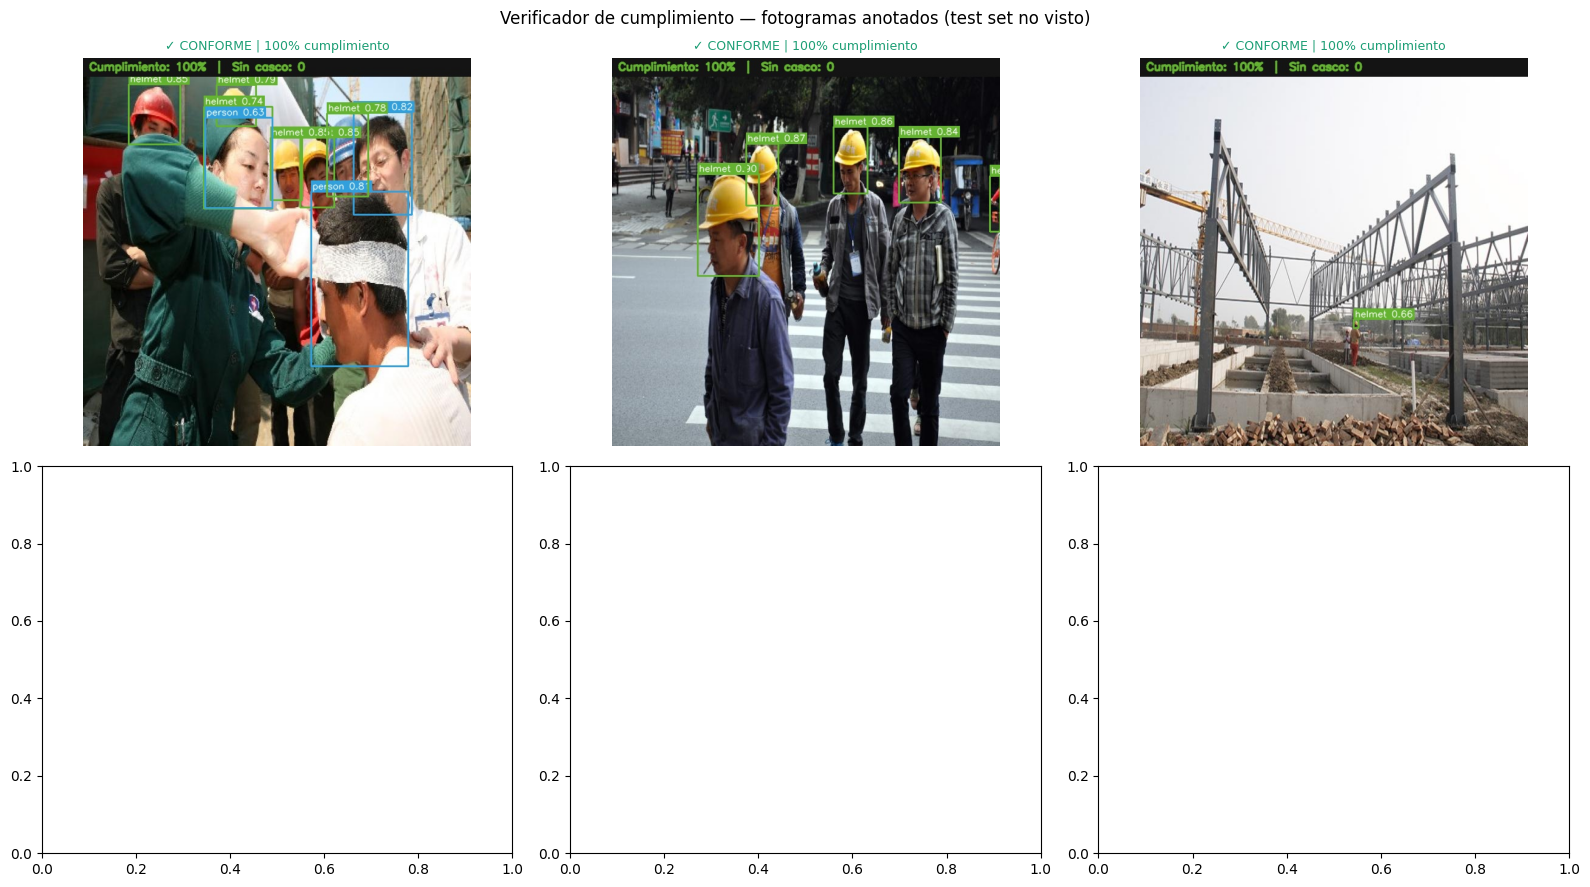

Demo guardado: exports/compliance_demo.png


In [34]:
# ── 7.5 · Visualización del verificador en acción ────────────────────────────
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import os

# Mostrar los 6 fotogramas más interesantes: 3 con no_helmet, 3 sin
df_c = df_compliance.copy()
non_compliant_frames = df_c[df_c['n_no_helmet'] > 0]['frame_id'].tolist()[:3]
compliant_frames     = df_c[df_c['n_no_helmet'] == 0]['frame_id'].tolist()[:3]
showcase_ids = non_compliant_frames + compliant_frames

annotated_files = sorted(DIRS['frames'].glob('*.jpg'))
frame_map = {int(f.stem.split('_')[1]): f for f in annotated_files}

n_show = min(6, len(showcase_ids))
if n_show > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, fid in zip(axes.flat, showcase_ids[:6]):
        if fid in frame_map:
            img = cv2.imread(str(frame_map[fid]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            row = df_c[df_c['frame_id'] == fid].iloc[0]
            status = '⚠ NO CONFORME' if row['n_no_helmet'] > 0 else '✓ CONFORME'
            rate   = row['compliance_rate'] * 100
            ax.set_title(f'{status} | {rate:.0f}% cumplimiento', fontsize=9,
                         color='#D85A30' if row['n_no_helmet'] > 0 else '#1D9E75',
                         fontweight='500')
        ax.axis('off')

    plt.suptitle('Verificador de cumplimiento — fotogramas anotados (test set no visto)',
                 fontsize=12, fontweight='500')
    plt.tight_layout()
    plt.savefig(DIRS['exports'] / 'compliance_demo.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Demo guardado: exports/compliance_demo.png')

Resumen de sesión de verificación:
  total_frames                       : 20
  mean_compliance                    : 1.0
  min_compliance                     : 1.0
  frames_non_compliant               : 0
  total_no_helmet_detections         : 0


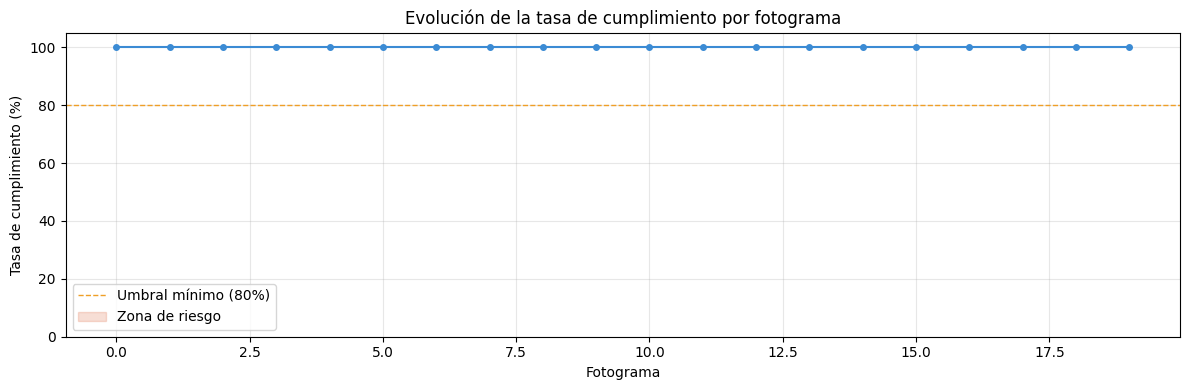

Timeline guardado: exports/compliance_timeline.png


In [35]:
# ── 7.6 · Resumen de sesión ───────────────────────────────────────────────────
from compliance_checker import summarize_session

session_summary = summarize_session(all_frame_results)
print('Resumen de sesión de verificación:')
for k, v in session_summary.items():
    print(f'  {k:35s}: {v}')

pd.DataFrame([session_summary]).to_csv(
    DIRS['exports'] / 'session_summary.csv', index=False
)

# Evolución de tasa de cumplimiento por fotograma
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_compliance['frame_id'], df_compliance['compliance_rate'] * 100,
        color='#3B8BD4', linewidth=1.5, marker='o', markersize=4)
ax.axhline(80, color='#EF9F27', linestyle='--', linewidth=1, label='Umbral mínimo (80%)')
ax.fill_between(df_compliance['frame_id'],
                df_compliance['compliance_rate'] * 100, 80,
                where=df_compliance['compliance_rate'] < 0.8,
                color='#D85A30', alpha=0.2, label='Zona de riesgo')
ax.set_ylim(0, 105)
ax.set_xlabel('Fotograma')
ax.set_ylabel('Tasa de cumplimiento (%)')
ax.set_title('Evolución de la tasa de cumplimiento por fotograma', fontweight='500')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DIRS['exports'] / 'compliance_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Timeline guardado: exports/compliance_timeline.png')

### Conclusión §7
> **Diseño del verificador:** El módulo `compliance_checker.py` es stateless, testeable y separado del modelo. Las reglas son configurables sin reentrenar — si el equipo de seguridad quiere bajar el umbral de confianza de 0.40 a 0.25 (más sensible, más FP), es un cambio de una línea en el dict `COMPLIANCE_RULES`.
>
> **Para la defensa:** El timeline de cumplimiento por fotograma es la visualización más impactante — muestra cuándo ocurren los incidentes y permite correlacionar con actividades de obra (inicio de turno, hora de almuerzo, trabajo en altura).

---
## §8 · Implicaciones Éticas

Esta sección constituye una reflexión obligatoria sobre las consecuencias sociales y operativas de implementar un sistema automatizado de vigilancia de seguridad laboral.

---

### 8.1 El balance entre Falsos Negativos y Falsos Positivos

En un sistema de seguridad ocupacional, los dos tipos de error tienen consecuencias asimétricas:

**Falso Negativo (FN):** El modelo no detecta a un trabajador sin casco. Consecuencia directa: el incumplimiento pasa desapercibido, el trabajador queda expuesto a riesgo de lesión cefálica sin intervención. En entornos de alta peligrosidad (trabajo en altura, presencia de maquinaria pesada), un FN puede tener consecuencias fatales. El costo de un FN es, en principio, ilimitado.

**Falso Positivo (FP):** El modelo marca a un trabajador que sí lleva casco como no conforme. Consecuencias: interrupción innecesaria del trabajo, erosión de la confianza en el sistema, potencial estigmatización del trabajador. Si el sistema genera muchos FP, los supervisores aprenden a ignorarlo — el "efecto alarma de lobo" — lo que neutraliza incluso los verdaderos positivos.

**Decisión de calibración:** El umbral de confianza del verificador debe calibrarse priorizando el recall de `no_helmet` sobre la precisión. Un recall de 0.90 con precisión de 0.70 es preferible a precisión 0.90 con recall 0.70. Esta decisión debe ser explícita, documentada y validada con el equipo de seguridad de la obra, no elegida automáticamente por el modelo.

---

### 8.2 Privacidad de los Trabajadores

El sistema procesa imágenes de personas en su lugar de trabajo. Surgen varias tensiones éticas:

**Vigilancia continua vs. seguridad:** El sistema puede percibirse como un mecanismo de control disciplinario más allá del EPP — rastrear productividad, pausas, interacciones. Aun cuando el propósito declarado es la seguridad, la tecnología es dual.

**Consentimiento informado:** Los trabajadores deben ser informados de que existe un sistema de visión artificial activo. Instalar cámaras de monitoreo sin información previa puede constituir una violación de derechos laborales dependiendo de la legislación (en Perú, el D. Leg. 1353 y la Ley 29733 de Protección de Datos Personales son relevantes).

**Minimización de datos:** El sistema no debe almacenar más datos de los necesarios. Las imágenes que no contienen incumplimientos no deberían persistir. Las detecciones deberían anonimizarse — reportar "1 trabajador sin casco en zona A" sin almacenar el fotograma identificable.

---

### 8.3 Sesgos en los Datos de Entrenamiento

Los tres datasets usados provienen predominantemente de obras de construcción de países del hemisferio norte (China, Europa, Norteamérica). Esto introduce sesgos potenciales:

**Sesgo de iluminación:** Las condiciones de luz de obras peruanas (luz solar andina, polvo, neblina costera) pueden diferir de las del dataset de entrenamiento, degradando el rendimiento.

**Sesgo de equipamiento:** Los cascos usados en obras locales pueden tener colores o formas distintos a los del dataset. Un casco amarillo de seguridad peruano con marcas diferentes puede no ser reconocido si el modelo solo vio cascos blancos o naranjas en el entrenamiento.

**Sesgo de contexto:** Las obras en height (Andes) pueden tener fondos, andamios y maquinaria visualmente distintos a los del dataset. El análisis de robustez en §6 comienza a cuantificar esto, pero una evaluación completa requeriría datos propios de obras locales.

**Recomendación:** Antes de desplegar en producción, recolectar al menos 500 imágenes de obras locales, anotar manualmente y evaluar el modelo en ese dominio específico. El ajuste fino (*fine-tuning*) con datos locales es el paso natural siguiente a este proyecto.

---

### 8.4 Consideraciones para el Despliegue Responsable

Un sistema de este tipo no debe reemplazar la supervisión humana — debe augmentarla. El verificador de cumplimiento es una herramienta de apoyo a decisiones, no un árbitro automático. Toda acción disciplinaria basada en detecciones automáticas debe incluir verificación humana. El sistema debe tener un mecanismo de apelación, y los trabajadores deben poder reportar falsos positivos que les afecten.

La métrica final de éxito de este sistema no es el mAP — es la reducción de accidentes laborales relacionados con el uso de casco, medida en el tiempo. La evaluación de impacto real requiere un diseño cuasi-experimental con grupos de control, que va más allá del alcance técnico de este proyecto pero es la pregunta que importa.

---
## Exportación Final de Artefactos

Celda de exportación consolidada — ejecutar al final para verificar que todos los entregables están en Drive.

In [36]:
# ── Verificación de artefactos exportados ────────────────────────────────────
import os

EXPECTED_ARTIFACTS = [
    ('dataset_inventory.csv',         'Inventario de datasets'),
    ('class_distribution_raw.png',    'Distribución de clases (raw)'),
    ('class_distribution_merged.png', 'Distribución de clases (fusionado)'),
    ('bbox_size_distribution.png',    'Distribución de tamaños de bbox'),
    ('augmentation_comparison.png',   'Comparativa de augmentation'),
    ('ablation_table.csv',            'Tabla de ablaciones A vs B'),
    ('training_curves.png',           'Curvas de entrenamiento Exp C'),
    ('metrics_per_class.csv',         'Métricas por clase'),
    ('metrics_global.csv',            'Métricas globales'),
    ('confusion_matrix.png',          'Matriz de confusión'),
    ('pr_curves.png',                 'Curvas Precision-Recall'),
    ('occlusion_split.csv',           'Partición por oclusión'),
    ('robustness_by_occlusion.csv',   'Robustez por grupo de oclusión'),
    ('robustness_report.png',         'Reporte de robustez visual'),
    ('compliance_checker.py',         'Módulo verificador de cumplimiento'),
    ('compliance_report.csv',         'Reporte de cumplimiento por fotograma'),
    ('compliance_demo.png',           'Demo visual del verificador'),
    ('compliance_timeline.png',       'Timeline de tasa de cumplimiento'),
    ('session_summary.csv',           'Resumen de sesión'),
]

print(f'Verificando artefactos en: {DIRS["exports"]}\n')
print(f'{"Artefacto":<42} {"Descripción":<38} {"Estado"}')
print('─' * 95)

missing = []
for filename, description in EXPECTED_ARTIFACTS:
    path = DIRS['exports'] / filename
    exists = path.exists()
    size   = f'{path.stat().st_size / 1024:.1f} KB' if exists else '—'
    status = f'✓ {size}' if exists else '✗ FALTANTE'
    print(f'{filename:<42} {description:<38} {status}')
    if not exists:
        missing.append(filename)

print(f'\n{"─" * 95}')
if missing:
    print(f'\n⚠ Artefactos faltantes ({len(missing)}): {missing}')
    print('  → Ejecutar las celdas correspondientes para generarlos.')
else:
    print(f'\n✓ Todos los {len(EXPECTED_ARTIFACTS)} artefactos exportados correctamente.')
    print(f'  Ruta en Drive: {DIRS["exports"]}')

Verificando artefactos en: /content/helmet_project/exports

Artefacto                                  Descripción                            Estado
───────────────────────────────────────────────────────────────────────────────────────────────
dataset_inventory.csv                      Inventario de datasets                 ✓ 0.1 KB
class_distribution_raw.png                 Distribución de clases (raw)           ✓ 39.0 KB
class_distribution_merged.png              Distribución de clases (fusionado)     ✓ 35.9 KB
bbox_size_distribution.png                 Distribución de tamaños de bbox        ✓ 50.2 KB
augmentation_comparison.png                Comparativa de augmentation            ✓ 965.4 KB
ablation_table.csv                         Tabla de ablaciones A vs B             ✓ 0.2 KB
training_curves.png                        Curvas de entrenamiento Exp C          ✓ 202.1 KB
metrics_per_class.csv                      Métricas por clase                     ✓ 0.2 KB
metrics_global.csv  

In [40]:
import shutil
from google.colab import files

shutil.make_archive("/content/helmet_project_backup", "zip", "/content/helmet_project")
files.download("/content/helmet_project_backup.zip")

shutil.make_archive("/content/yolov9_backup", "zip", "/content/yolov9")
files.download("/content/yolov9_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>